In [6]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
import matplotlib.pyplot as plt

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

plt.rcdefaults()

RCPARAMS = {
    'axes.formatter.limits': (-3, 3),
    'savefig.bbox': 'tight',
}
mpl.rcParams.update(RCPARAMS)

In [7]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "baseline_2-50keV_1ks"

RUN_ID: str = 'IROSbenchmrk_detected_2-5keV'
E_min, E_max = 2.0, 5.0           # [keV]

ID_CAMERA_A: str = "cam1a"
DATASET: str = 'detected'

In [8]:
from bloodmoon.images import _erosion

def apply_oldVignetting(
    camera: CodedMaskCamera,
    shadowgram: NDArray,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    r"""
    Apply vignetting effects to a shadowgram based on source position.
    """    
    def project_mask_thickness(shift: float, bin_dim: float) -> float:
        """
        Projects the mask thickness on the mask binning elements, and
        corrects the projection value to allows for correct erosion
        of the mask physical elements starting from the pixels' edges.
        """
        # since the mask detector distance is defined as the distance between the
        # detector top and the mask top, erosion shall cut on the left-side of the
        # shadowgram when sources have negative `angle`.
        # if the mask detector distance was defined as the distance between the
        # detector top and the mask bottom, erosion should have been applied to the
        # right side, i.e. `proj` should be multiplied by -1.
        angle = np.arctan(shift / camera.specs.mask_detector_distance)
        proj = camera.specs.mask_thickness * np.tan(angle)
        shift_px = shift / bin_dim
        # the mask thickness projection has to be corrected by considering the
        # erosion pixel start point, due to the discretisation of the projection
        # https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/new_erosion_20251024.ipynb
        bin_erosion_start = (1.0 - abs(shift_px - int(shift_px))) * bin_dim
        return proj + np.sign(proj) * bin_erosion_start
    
    bins = camera.bins_detector
    bin_dim_x, bin_dim_y = (
        bins.x[1] - bins.x[0],
        bins.y[1] - bins.y[0],
    )

    red_factor_x = project_mask_thickness(shift_x, bin_dim_x)
    sg_x = _erosion(shadowgram, bin_dim_x, red_factor_x)

    # - we apply the y-axis erosion to `sg_x`, otherwise the decimal
    #   values of the input shifted shadowgram would be squared
    # - the erosion on the two axes is still independent, as it must be
    red_factor_y = project_mask_thickness(shift_y, bin_dim_y)
    sg_y = _erosion(sg_x.T, bin_dim_y, red_factor_y)

    return sg_y.T

In [9]:
VIGNETTING: bool | Callable = apply_oldVignetting
PSFY: bool | Callable = mgm.config_psfy_flag(DATASET)

In [10]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

logA, _ = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


CATALOG ='IROS_benchmark_catalogue_1ks.fits' / Catalog file                      [astropy.io.fits.card]


In [11]:
def set_phase(x: NDArray) -> NDArray:
    """Centers x values around zero."""
    return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
def find_tick_val(ticks: NDArray, trg_vals: NDArray, atol: float = 1e-2) -> NDArray:
    """Finds the idxs inside `ticks` relative to given values `trg_vals`."""
    trg_idxs: list[int] = []
    for v in trg_vals:
        idx = np.argwhere(np.isclose(ticks, v, atol=atol))
        if idx.size > 0: trg_idxs.append(idx[0, 0])
    return np.array(trg_idxs)

def show_SPSF(
    camera: CodedMaskCamera,
    psf: NDArray,
    modelled: NDArray,
    srcID: str | None = None,
    save_to: str | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Plots the SPSF heat maps and profiles along fine/coarse axes + cfr with modelled source.
    """
    title_fs = 16
    lbl_fs = 14
    # setup
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    residues = (psf - modelled) * 100 / psf.max()
    n, m = psf.shape
    xslice, yslice = zip(
        *tuple((c[(n - 1) // 2, :], c[:, (m - 1) // 2]) for c in (psf, modelled, residues))
    )
    slice_clrs = ('OrangeRed', 'DodgerBlue')
    # plot figure
    fig, axs = plt.subplots(2, 3, tight_layout=True, **fig_kws)
    axs = axs.flatten()
    
    # ------------------------ SPFS HEAT MAPS ------------------------
    img_layout = {'origin': 'lower', 'interpolation': 'none', 'aspect': 2 * m / n}
    yticks, xticks = map(lambda s: np.arange(0, s), psf.shape)
    _ytick_lbls, _xtick_lbls = (
        dty / 60 * (yticks - len(yticks) // 2), dtx * (xticks - len(xticks) // 2),
    )
    yticks_ = find_tick_val(_ytick_lbls, np.array([-5.0, -2.5, 0.0, 2.5, 5.0]), atol=7e-2)
    yticks_lbl = [float(f'{t:.1f}') for t in _ytick_lbls[yticks_]]
    xticks_ = find_tick_val(_xtick_lbls, np.array([-6.35, 0.0, 6.35]), atol=1e-3)
    xticks_lbl = [float(f'{t:.1f}') for t in _xtick_lbls[xticks_]]

    axs[0].set_title(f'{srcID or 'Src'} SPFS', fontsize=title_fs)
    psf_img = axs[0].imshow(psf, cmap='gist_heat', **img_layout)
    cbar = fig.colorbar(psf_img, ax=axs[0], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('counts [ph]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[0].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[0].set_ylabel(ylabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    axs[3].set_title(f'{srcID or 'Src'} SPFS Residues', fontsize=title_fs)
    mod_img = axs[3].imshow(residues, **img_layout)
    cbar = fig.colorbar(mod_img, ax=axs[3], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('residues counts [%]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[3].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[3].set_ylabel(ylabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    for idx in [0, 3]:
        axs[idx].set_xticks(xticks_, xticks_lbl)
        axs[idx].set_yticks(yticks_, yticks_lbl)

    # ------------------------ SPFS PROFILES | FINE AXIS ------------------------
    x = dtx * set_phase(xslice[0])

    axs[1].set_title('SPFS Slice - Fine Axis', fontsize=title_fs)
    axs[1].stairs(xslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[1].stairs(xslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[1].set_ylim(-3e4, None)
    axs[1].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[1].yaxis.tick_right()

    axs[4].set_title('SPFS Slice Residues - Fine Axis', fontsize=title_fs)
    axs[4].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[4].stairs(xslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[4].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[4].yaxis.tick_right()

    # ------------------------ SPFS PROFILES | COARSE AXIS ------------------------
    x = dty * set_phase(yslice[0]) / 60

    axs[2].set_title('SPFS Slice - Coarse Axis', fontsize=title_fs)
    axs[2].stairs(yslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[2].stairs(yslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[2].set_ylim(-3e4, None)
    axs[2].set_xlabel(xlabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[2].set_ylabel(ylabel='counts [ph]', labelpad=10, fontsize=lbl_fs)
    axs[2].yaxis.set_label_position('right')
    axs[2].yaxis.tick_right()

    axs[5].set_title('SPFS Slice Residues - Coarse Axis', fontsize=title_fs)
    axs[5].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[5].stairs(yslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[5].set_xlabel(xlabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[5].set_ylabel(ylabel=r'residues counts [%]', labelpad=10, fontsize=lbl_fs)
    axs[5].yaxis.set_label_position('right')
    axs[5].yaxis.tick_right()


    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5, labelsize=lbl_fs)
    for idx in [1, 2, 4, 5]:
        axs[idx].legend(loc='best')

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    
    plt.show()
    return

In [12]:
detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

In [13]:
from bloodmoon.images import argmax
from darksun.data import Log

def subtract_previous(
    camera: CodedMaskCamera,
    log: Log,
    src_idx: int,
    true: NDArray,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Subtracts sources previous to IROS src index in `log`."""
    sky = true.copy()
    for idx in range(src_idx):
        modelled = model_sky(
            camera, log.log['shift_x'][idx], log.log['shift_y'][idx],
            log.log['fluence'][idx], vignetting=vignetting, psfy=psfy
        )
        sky -= modelled
    return sky

def find_boxmax(sky: NDArray, centre: tuple[int, int], boxsize: int = 5) -> tuple[int, int]:
    """Finds the argmax of given sky in a box centered around `pos`."""
    rcut, ccut = map(lambda idx: slice(idx - boxsize, idx + boxsize + 1), centre)
    p, q = centre
    n, m = argmax(sky[rcut, ccut])
    return p - boxsize + n, q - boxsize + m



IDX: int = 5   # src IDX in reconstruction

base_sky = subtract_previous(wfm, logA, IDX, true_skyA, VIGNETTING, PSFY)
SRC_DATA = {
    'srcID': logA.log['ID'][IDX],
    'sx': logA.log['shift_x'][IDX],
    'sy': logA.log['shift_y'][IDX],
    'cts': logA.log['fluence'][IDX],
    'pos': (logA.log['y'][IDX], logA.log['x'][IDX]), #find_boxmax(base_sky, (logA.log['y'][IDX], logA.log['x'][IDX])),
    'crp': (35, 3),
}

template = model_sky(wfm, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], vignetting=VIGNETTING, psfy=PSFY)
src_psf, src_model = map(lambda x: ds.crop(x, SRC_DATA['pos'], SRC_DATA['crp']), (base_sky, template))

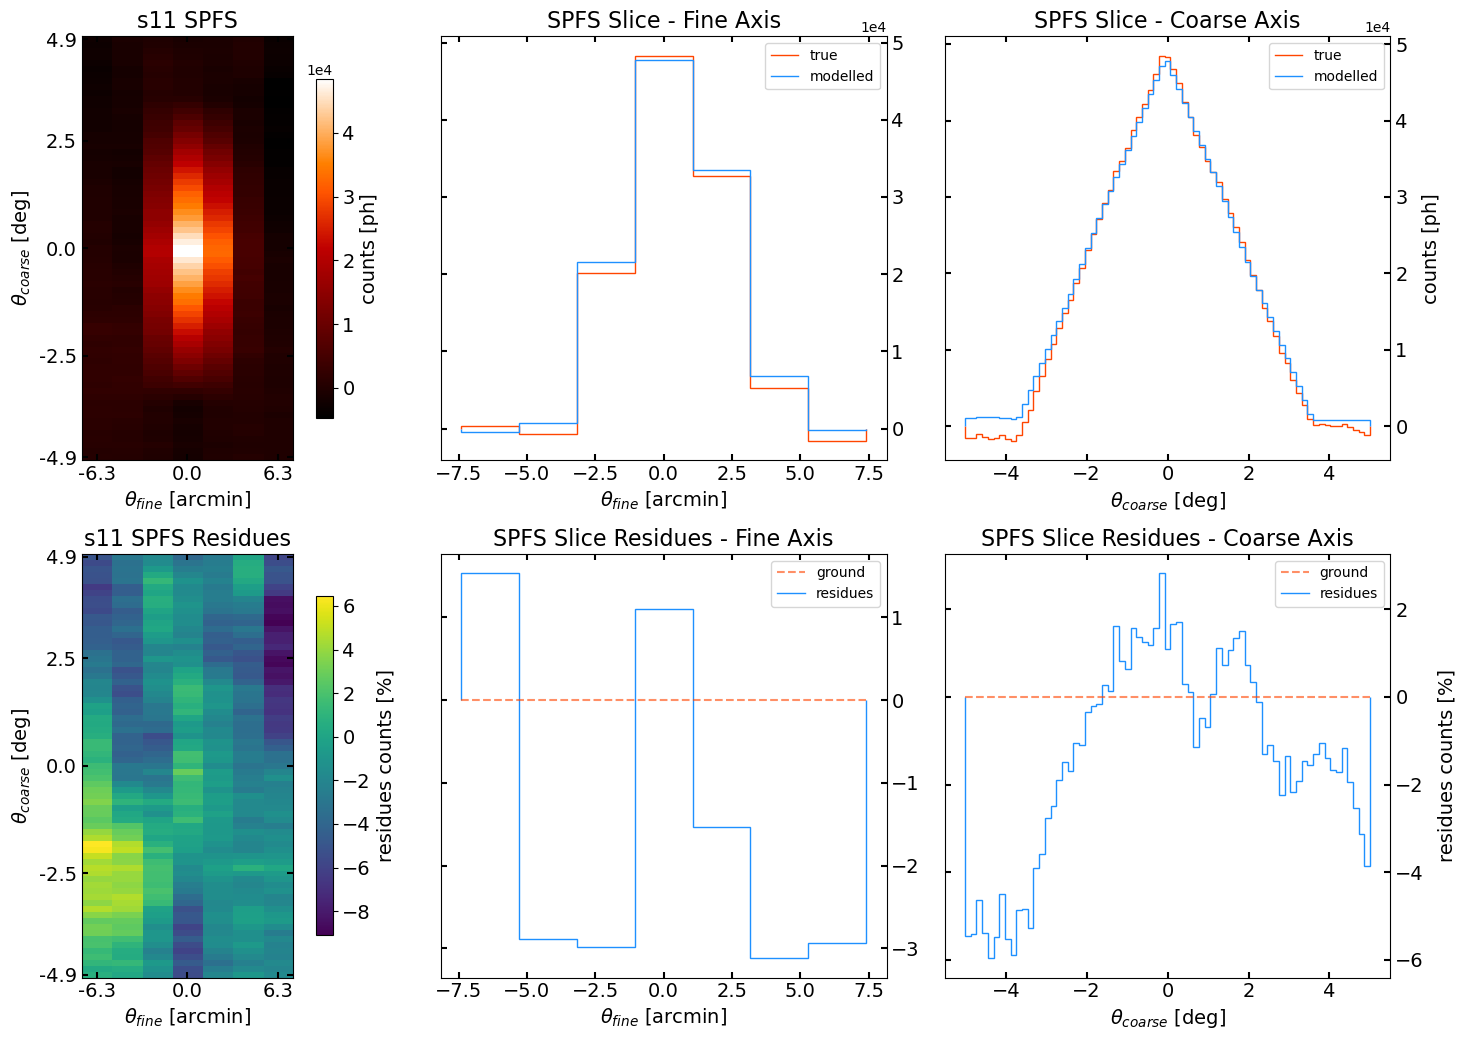

In [14]:
show_SPSF(
    camera=wfm,
    psf=src_psf,
    modelled=src_model,
    srcID=SRC_DATA['srcID'],
    # save_to=f'{OUT_RESULTS_PATH}/Crab_1ks_{E_min}-{E_max}keV.pdf',
    figsize=(5 * 3 + 0.5, 5 * 2 + 0.5),
)

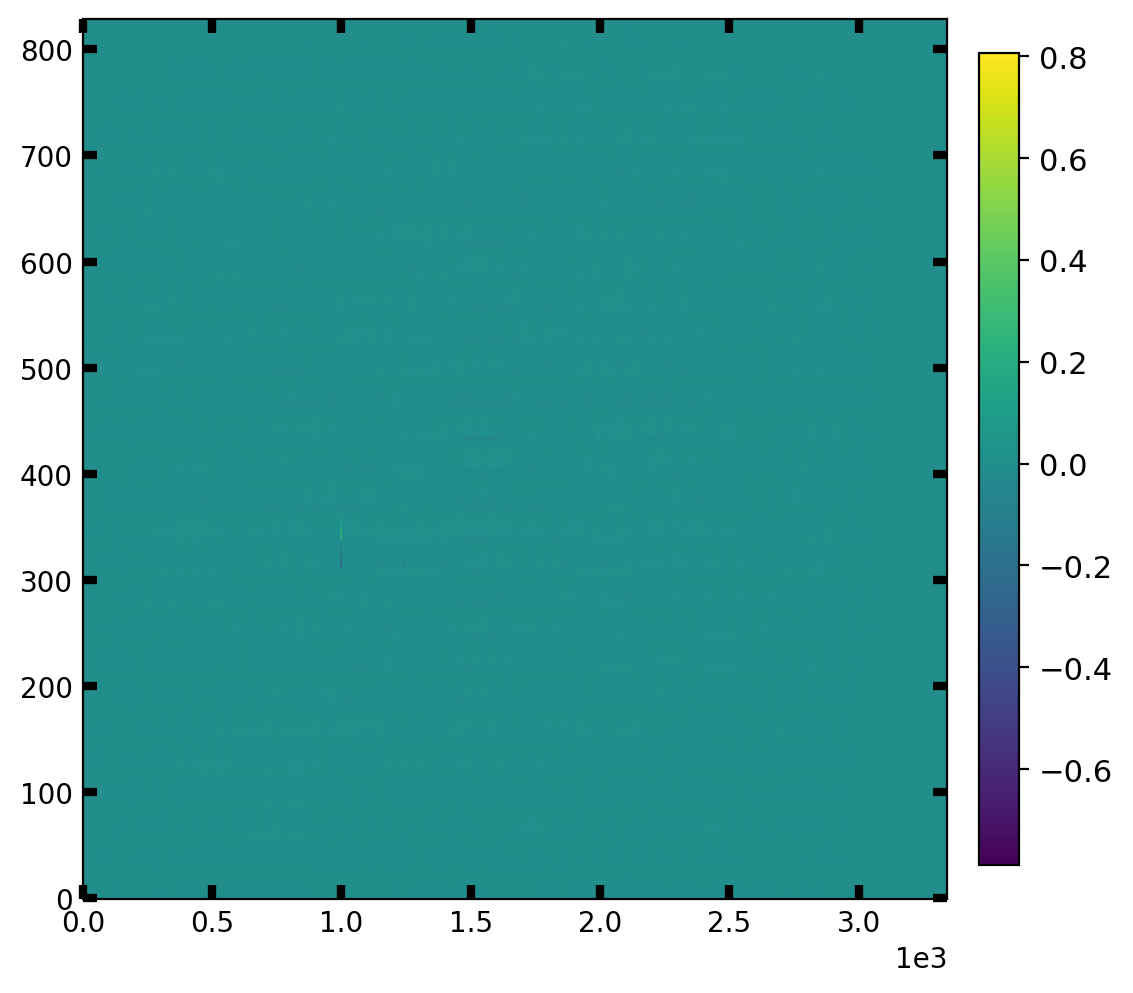

In [15]:
# NOTE: test vignetting


cts = 1e4

src_model_old = model_sky(
    camera=wfm,
    shift_x=SRC_DATA['sx'],
    shift_y=SRC_DATA['sy'],
    fluence=cts,
    vignetting=apply_oldVignetting,
    psfy=False,
)
src_model = model_sky(
    camera=wfm,
    shift_x=SRC_DATA['sx'],
    shift_y=SRC_DATA['sy'],
    fluence=cts,
    psfy=False,
)


ds.image_plot(ds.map4image((src_model_old - src_model) * 100 / cts, img_kwargs=dict(aspect=wfm.shape_detector[1]/wfm.shape_detector[0])))

In [16]:
from astropy.io.fits import FITS_rec
from bloodmoon.types import CoordEquatorial

from bloodmoon.coords import equatorial2shift
from bloodmoon.optim import model_shadowgram
from darksun.benchmarking import source_catalogue_data
from darksun.data import CatalogueLoader

def get_source_coords(sourceID: str, catalogue: CatalogueLoader) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def select_target_srcs(
    photons: FITS_rec,
    srcIDs: str | tuple[str, ...],
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Filters the input photon list for the given sources equatorial coords."""
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    coords = tuple(get_source_coords(src, catalogue) for src in srcIDs_)
    phs = ds.select_source_photons(coords, photons, False)
    return phs

def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the y axis
            - collapsed array along the x axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)

def extract_section(
    arr: NDArray,
    rows: slice,
    cols: slice,
) -> NDArray:
    """Returns an array view of the input array."""
    return arr[rows, cols]

In [17]:
wfm: CodedMaskCamera = codedmask(MASK_PATH, 10, 1)

In [18]:
srcID: str = 's17'

phs: FITS_rec = select_target_srcs(sdlA.DLdata, srcID, catA)
detector, _ = count(wfm, phs)
true_skyA = decode(wfm, detector)

CATALOG ='IROS_benchmark_catalogue_1ks.fits' / Catalog file                      [astropy.io.fits.card]


In [19]:
sx, sy = equatorial2shift(sdlA, wfm, *get_source_coords(srcID, catA))

sg_model_old = model_shadowgram(
    camera=wfm,
    shift_x=sx,
    shift_y=sy,
    vignetting=apply_oldVignetting,
    psfy=False,
) * detector.sum()
sky_model_old = model_sky(
    camera=wfm,
    shift_x=sx,
    shift_y=sy,
    fluence=detector.sum(),
    vignetting=apply_oldVignetting,
    psfy=False,
)

sg_model = model_shadowgram(
    camera=wfm,
    shift_x=sx,
    shift_y=sy,
    psfy=False,
) * detector.sum()
sky_model = model_sky(
    camera=wfm,
    shift_x=sx,
    shift_y=sy,
    fluence=detector.sum(),
    psfy=False,
)

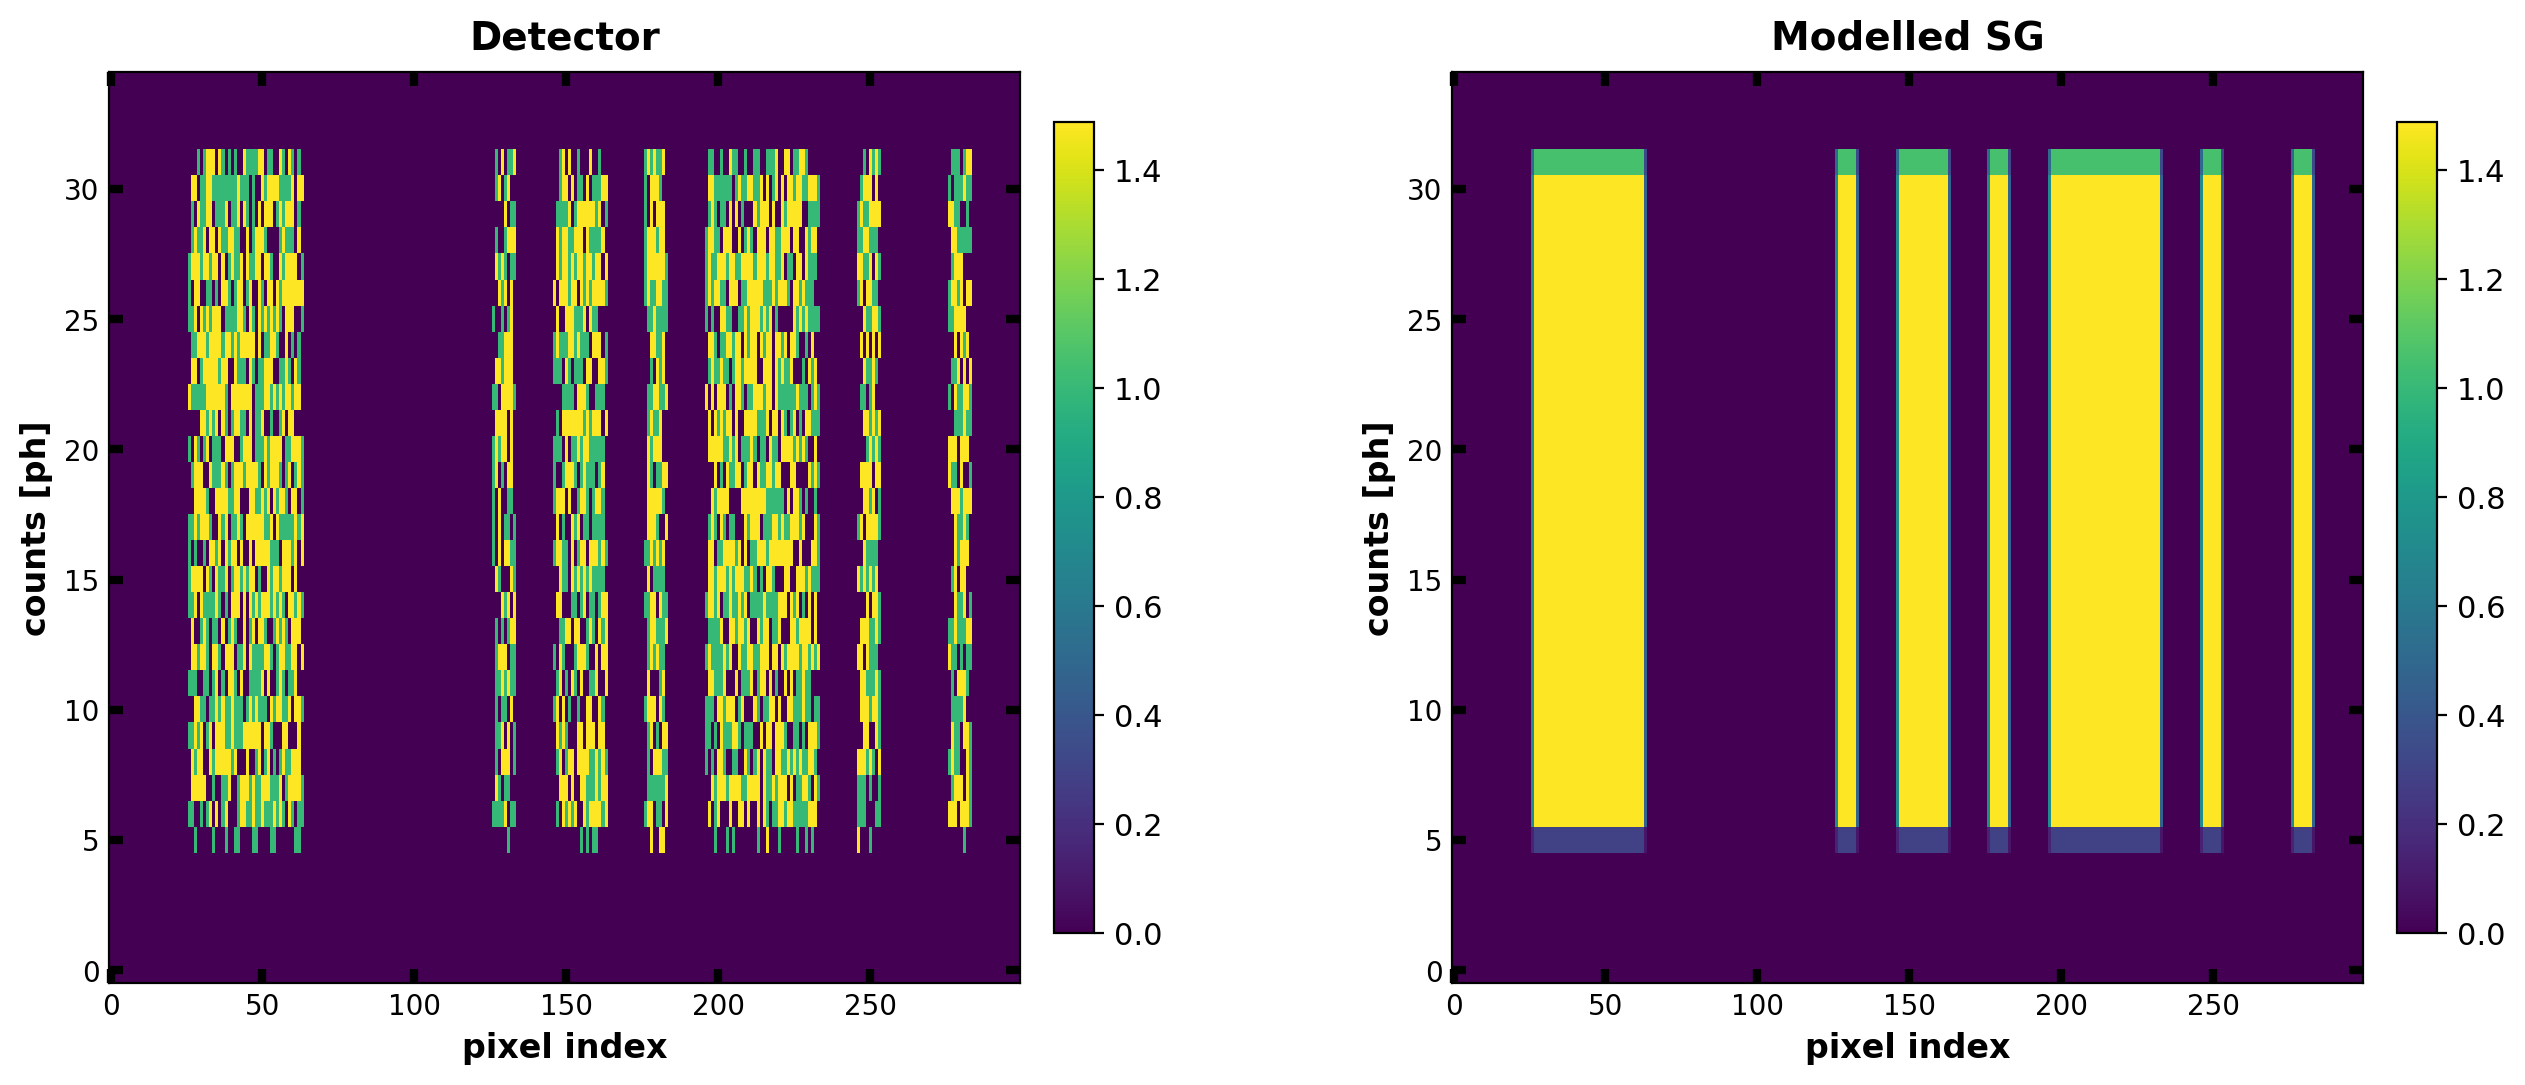

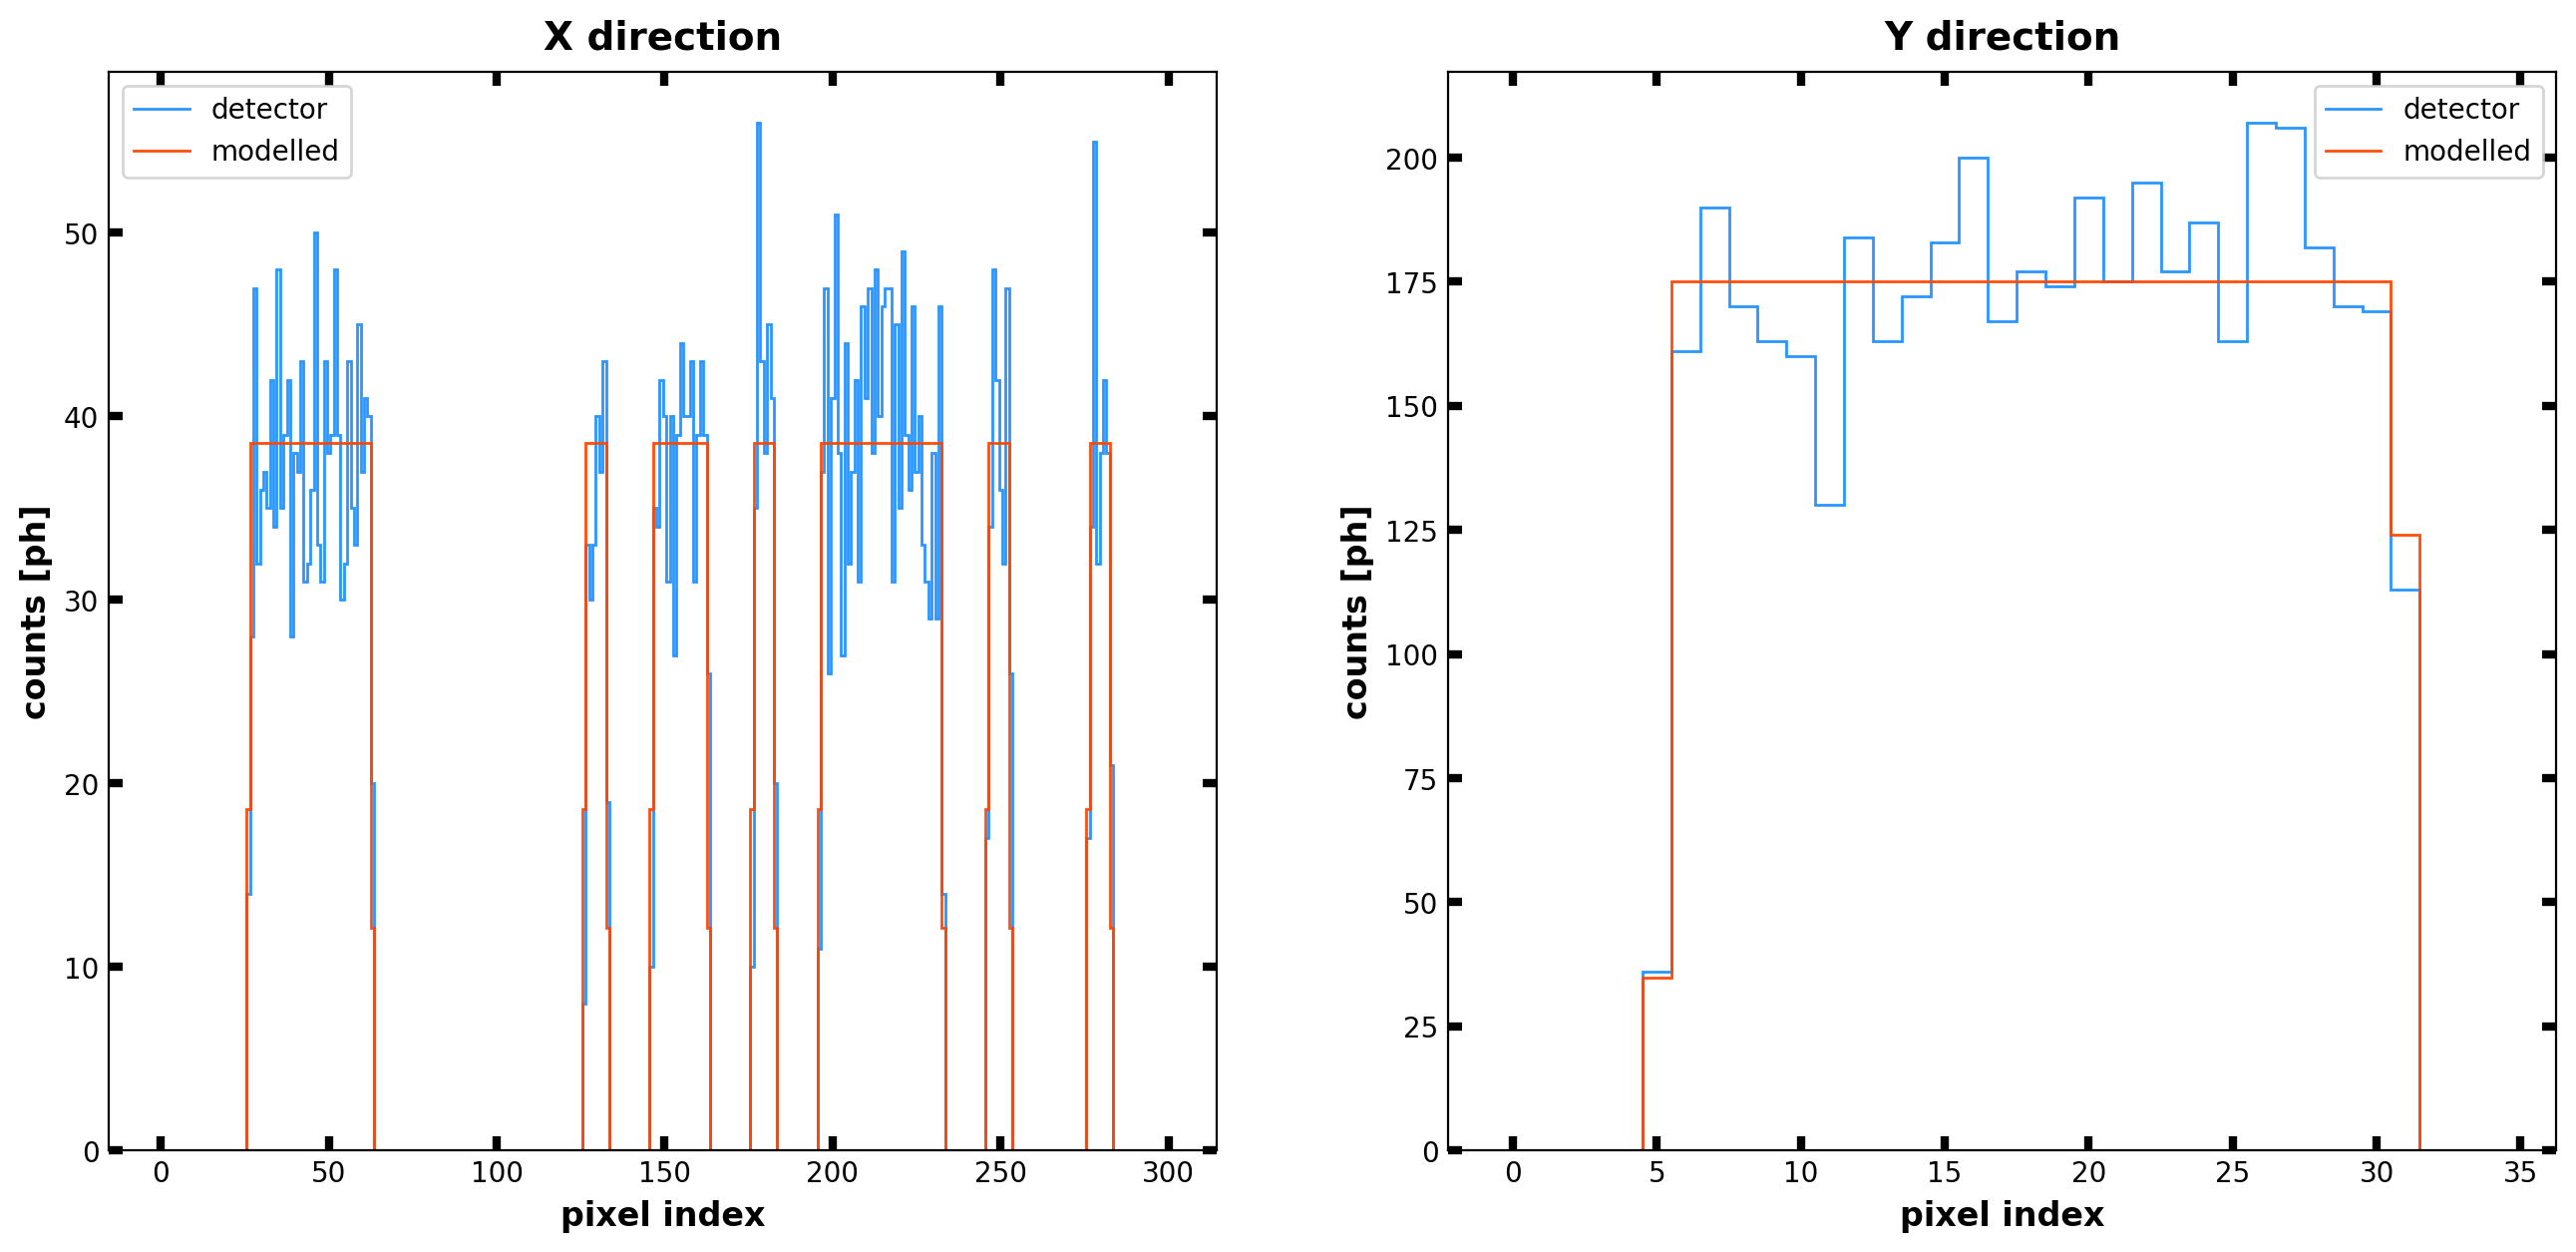

In [31]:
slicerows, slicecols = slice(165, 200), slice(2300, 2600)
ext_det, ext_sg = map(
    lambda x: extract_section(x, slicerows, slicecols),
    (detector, sg_model),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

ASPECT = ext_det.shape[1] / ext_det.shape[0]
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': ASPECT,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': ASPECT,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)

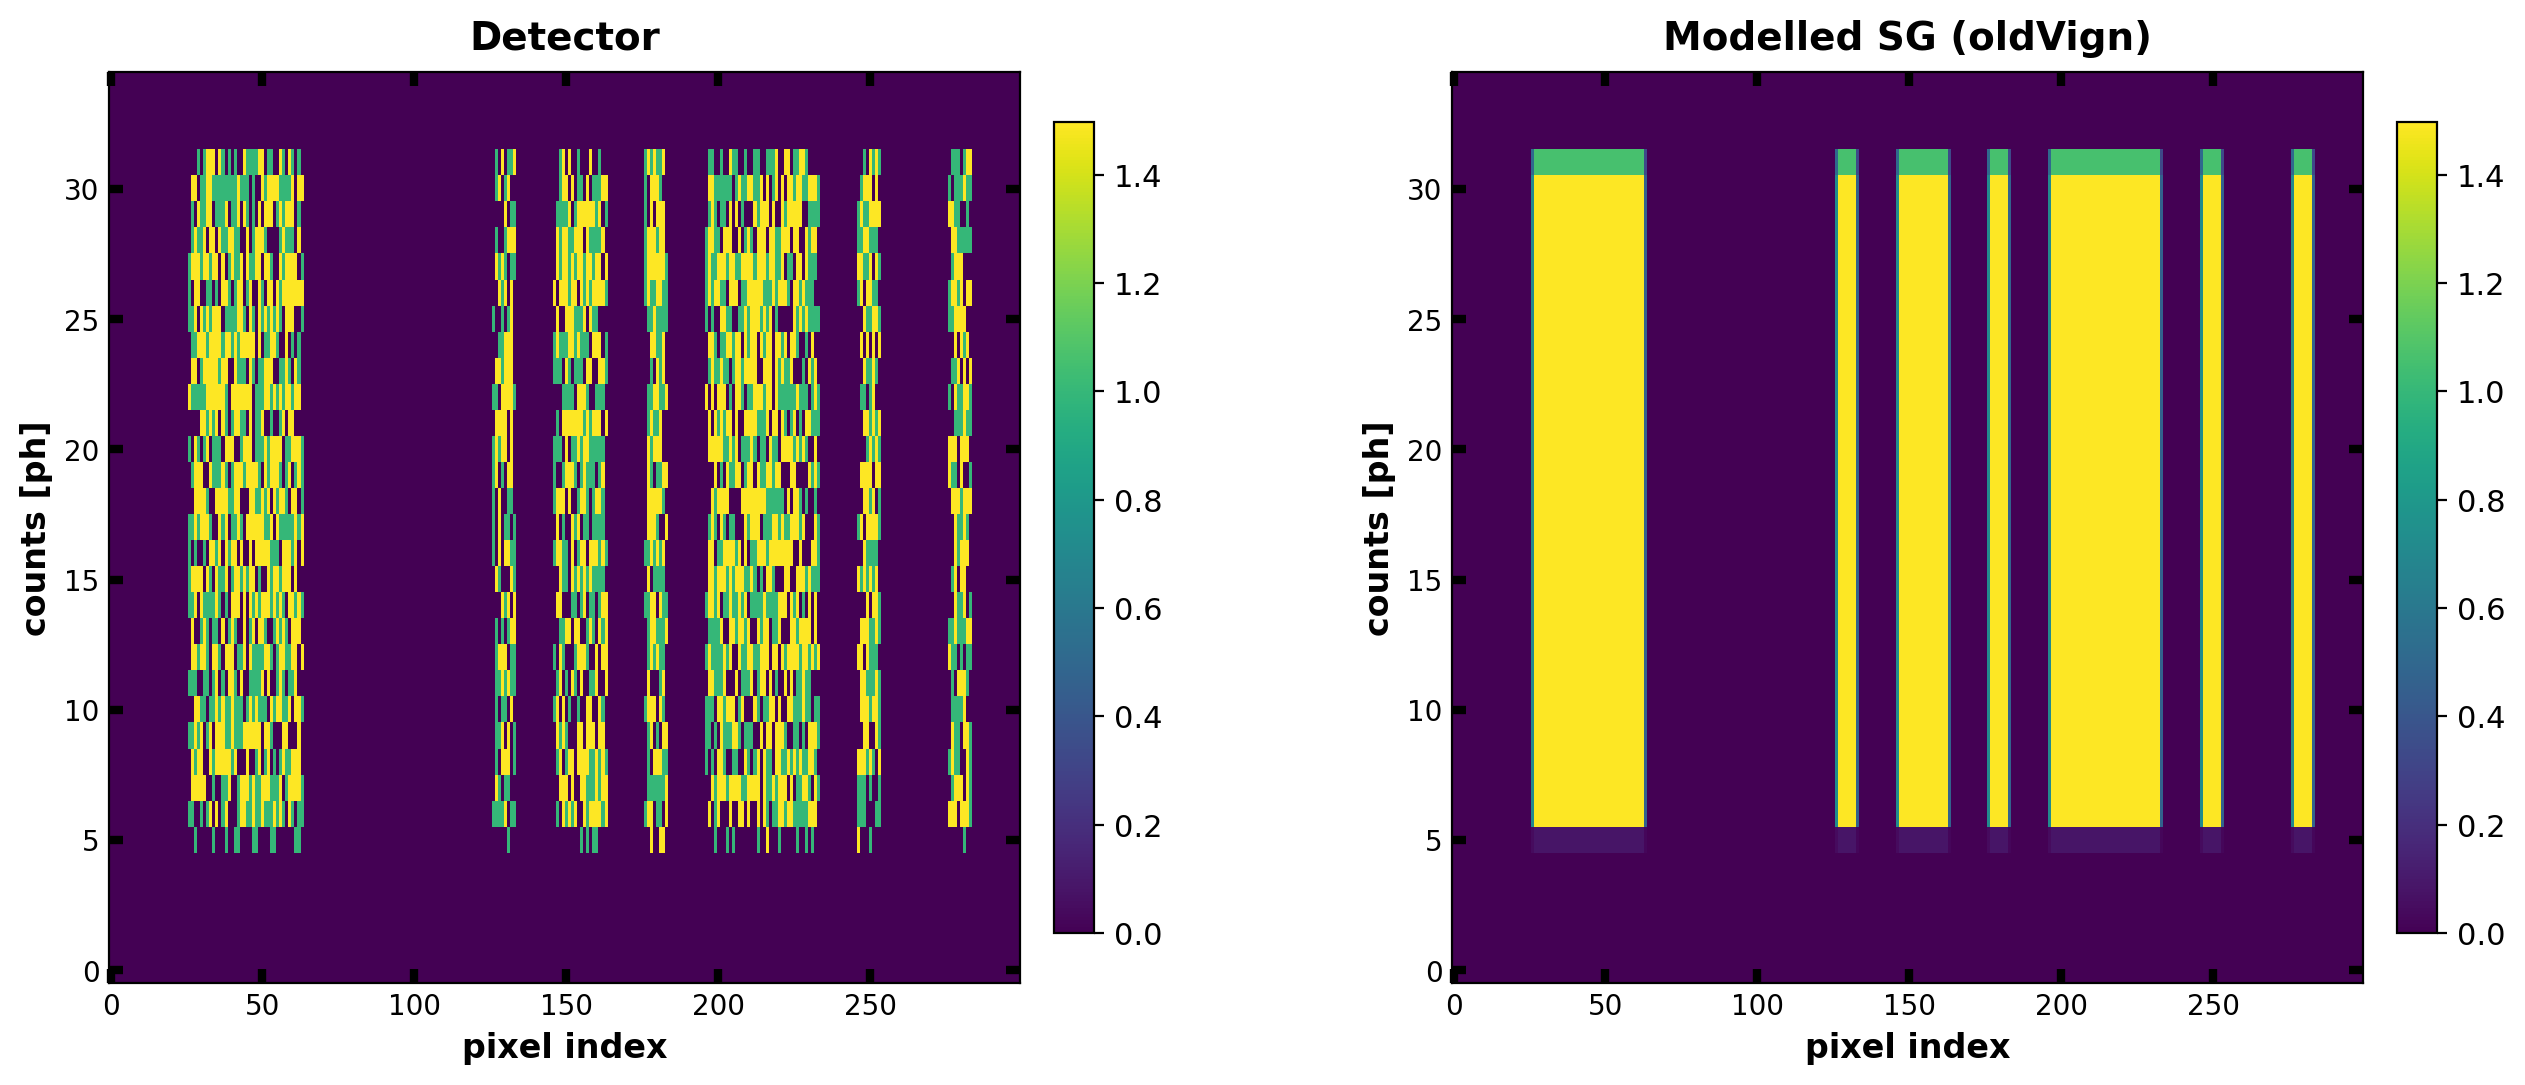

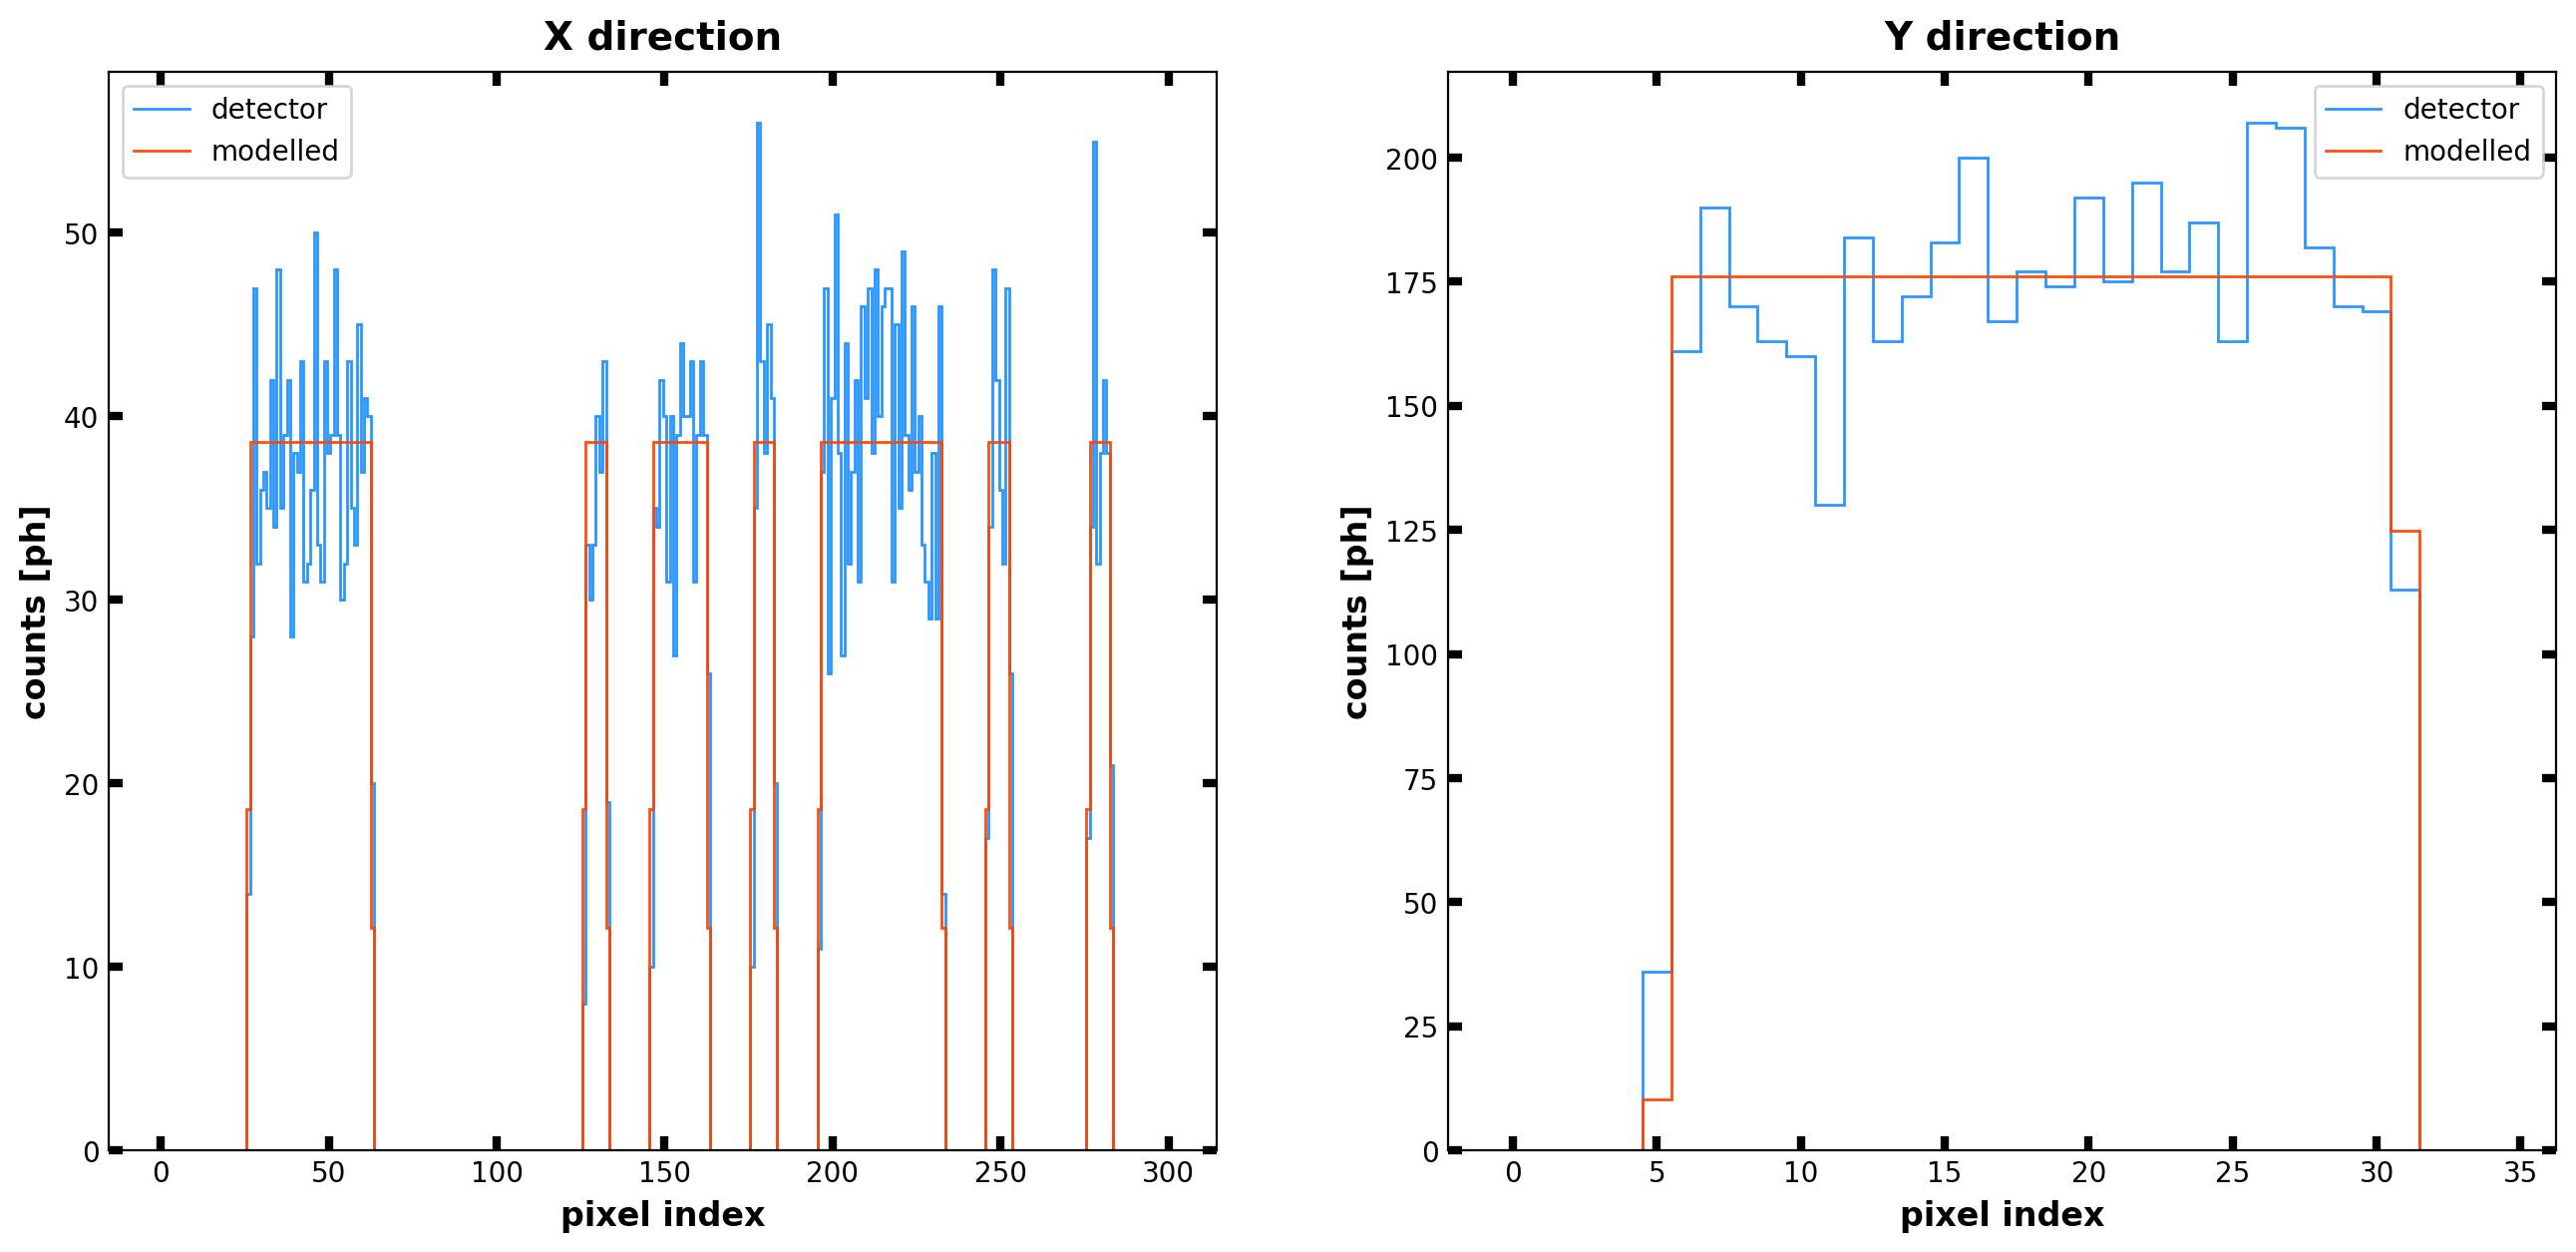

In [33]:
slicerows, slicecols = slice(165, 200), slice(2300, 2600)
ext_det, ext_sg = map(
    lambda x: extract_section(x, slicerows, slicecols),
    (detector, sg_model_old),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

ASPECT = ext_det.shape[1] / ext_det.shape[0]
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': ASPECT,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG (oldVign)',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': ASPECT,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)